# **bpnet-lite pipeline**

**Taken from:** https://bpnet-lite.readthedocs.io/en/latest/tutorials/Intro_What_Is_ChromBPNet.html

## **Evaluating Model Performance**

In [1]:
#from tangermeme.io import extract_loci

#peaks="/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/test_lactotrophs/chrombpnet_model/auxiliary/filtered.peaks.bed"
#seq="/scratch/prj/stem_cells_pituitary/Georgia/genome/mm10.fa"
#signals="/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/test_lactotrophs/chrombpnet_model/auxiliary/data_unstranded.bw"
#controls="/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/test_lactotrophs/chrombpnet_model/auxiliary/data_unstranded.bw"

#test_chroms=['chr1', 'chr3', 'chr6']

#X, y, X_ctl = extract_loci(peaks, seq, signals, in_signals=controls, chroms=test_chroms, verbose=True)
#X.shape, X_ctl.shape, y.shape

## **Using ChromBPNet**

In [6]:
# Import packages necessary

## See where packages are being loaded
print(sys.executable)

#! pip install bpnet-lite

#import os 
#import sys

#from bpnetlite.chrombpnet import ChromBPNet
#import torch

#!nvidia-smi

/scratch/users/k25055720/conda_envs/bpnet_lite/bin/python


In [7]:
# Load Models into the environment

# Tn5 Bias Model
bias_model="/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/test_lactotrophs/bias_model/models/bias.h5"
# ChromBPNet Model
chrombpnet_model="/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/test_lactotrophs/chrombpnet_model/models/chrombpnet_nobias.h5"

In [8]:
# Make chrombpnet object for use

chrombpnet = ChromBPNet.from_chrombpnet(
    bias_model,
    chrombpnet_model
)

chrombpnet

ChromBPNet(
  (bias): BPNet(
    (iconv): Conv1d(4, 128, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
    )
    (rrelus): ModuleList(
      (0-3): 4 x ReLU()
    )
    (fconv): Conv1d(128, 1, kernel_size=(75,), stride=(1,), padding=(37,))
    (linear): Linear(in_features=128, out_features=1, bias=True)
  )
  (accessibility): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1

In [9]:
# Pull out the accessibility model
chrombpnet.accessibility

BPNet(
  (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
  (irelu): ReLU()
  (rconvs): ModuleList(
    (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
    (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
    (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
    (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
    (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
    (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
    (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
    (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
  )
  (rrelus): ModuleList(
    (0-7): 8 x ReLU()
  )
  (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding=(37,))
  (linear): Linear(in_features=512, out_features=

In [10]:
# Pull out the bias model
chrombpnet.bias

BPNet(
  (iconv): Conv1d(4, 128, kernel_size=(21,), stride=(1,), padding=(10,))
  (irelu): ReLU()
  (rconvs): ModuleList(
    (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
    (1): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
    (2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
    (3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
  )
  (rrelus): ModuleList(
    (0-3): 4 x ReLU()
  )
  (fconv): Conv1d(128, 1, kernel_size=(75,), stride=(1,), padding=(37,))
  (linear): Linear(in_features=128, out_features=1, bias=True)
)

## **Predicting Accessibility and Bias**

The next step after loading the ChromBPnet models.

Load in peaks from the corresponding peak file and try predicting the accessibility of them.

In [11]:
# Load in peaks file packages
from tangermeme.io import extract_loci
from tangermeme.predict import predict

In [12]:
# Load in peaks file
# n_loci = 150 selects the first 150 genomic regions inside the bed file
X = extract_loci(
    "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/consensus_chromatin_landscape_modified.bed.gz",
    "/scratch/prj/stem_cells_pituitary/Georgia/genome/mm10.fa",
    n_loci= 150,
    verbose=True
)

y_profile, y_counts = predict(chrombpnet, X)
y_profile.shape, y_counts.shape

Loading Loci:   0%|          | 149/245876 [00:00<10:15, 399.38it/s]


(torch.Size([150, 1, 1000]), torch.Size([150, 1]))

There are 3 ways to make predictions from the ChromBPNet model:
- From the full model to match experimental readouts
- From the bias model to capture the sequence specificity of the cutting enzyme
- From the accessibility model to predict true accessibility after factorizing out the bias

In [13]:
# y = full model, predicts total observed signal (both real accessibility and technical noise)
y = predict(chrombpnet, X)[0]

# y_acc is the accessibility model -> predicts the true "cleaned" biological signal
y_acc = predict(chrombpnet.accessibility, X)[0]

# y_bias is the bias model alone -> shows where Tn5 likes to cut
y_bias = predict(chrombpnet.bias, X)[0]
# Bias model has less layers than accessibility, so it needs extra trimming to match dimensions
y_bias = y_bias[:, :, y_bias.shape[-1]//2-500:y_bias.shape[-1]//2+500]

# Softmax turns the models into "probability space" -> show the "probability tracks"
y_softmax = torch.softmax(y, dim=-1)
y_bias_softmax = torch.softmax(y_bias, dim=-1)
y_acc_softmax = torch.softmax(y_acc, dim=-1)

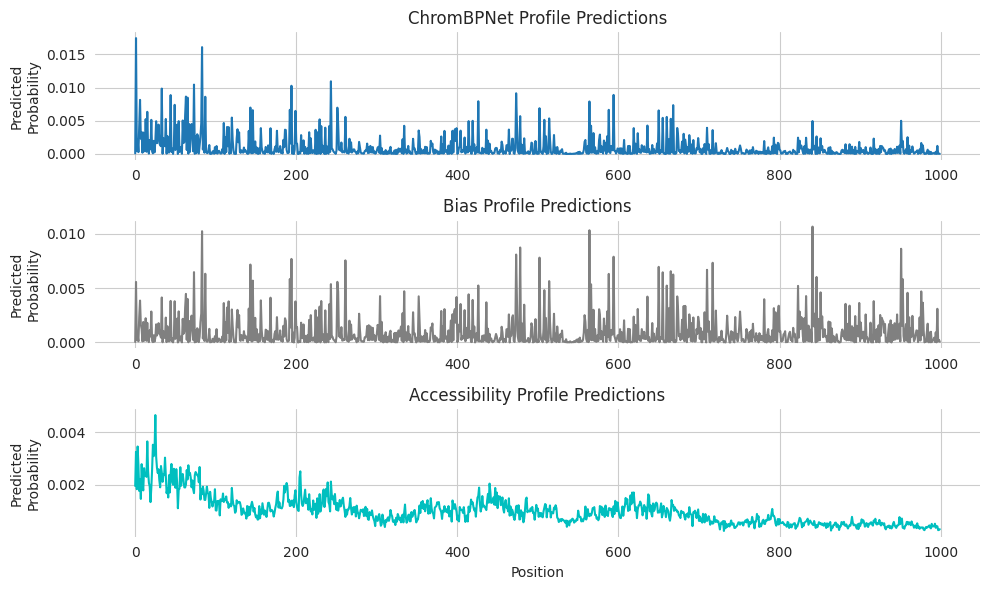

In [16]:
# Plot the above calculations on a random region

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('whitegrid')

# Select region from top 150 selected above
idx = 60

plt.figure(figsize=(10, 6))

plt.subplot(311)
plt.title("ChromBPNet Profile Predictions")
plt.plot(y_softmax[idx, 0])
seaborn.despine(bottom=True, left=True)
plt.ylabel("Predicted\nProbability")

plt.subplot(312)
plt.title("Bias Profile Predictions")
plt.plot(y_bias_softmax[idx, 0], c='0.5')
seaborn.despine(bottom=True, left=True)
plt.ylabel("Predicted\nProbability")

plt.subplot(313)
plt.title("Accessibility Profile Predictions")
plt.plot(y_acc_softmax[idx, 0], c='c')
seaborn.despine(bottom=True, left=True)
plt.ylabel("Predicted\nProbability")
plt.xlabel("Position")

plt.tight_layout()
plt.show()

The above doesn't tell us much.
We selected top 150 entries in the coordinates file: consensus_chromatin_landscape.bed.gz
The model we're currently looking at is also just one ATAC-seq dataset on ONE cell type (Lactotrophs). 
It is therefore not expected to see massive changes in accessibility across all coordinates because we've started so small and on such a niche.

It does, however, seem to be getting rid of spiky noise quite well, provided it's predicted true noise correctly. 

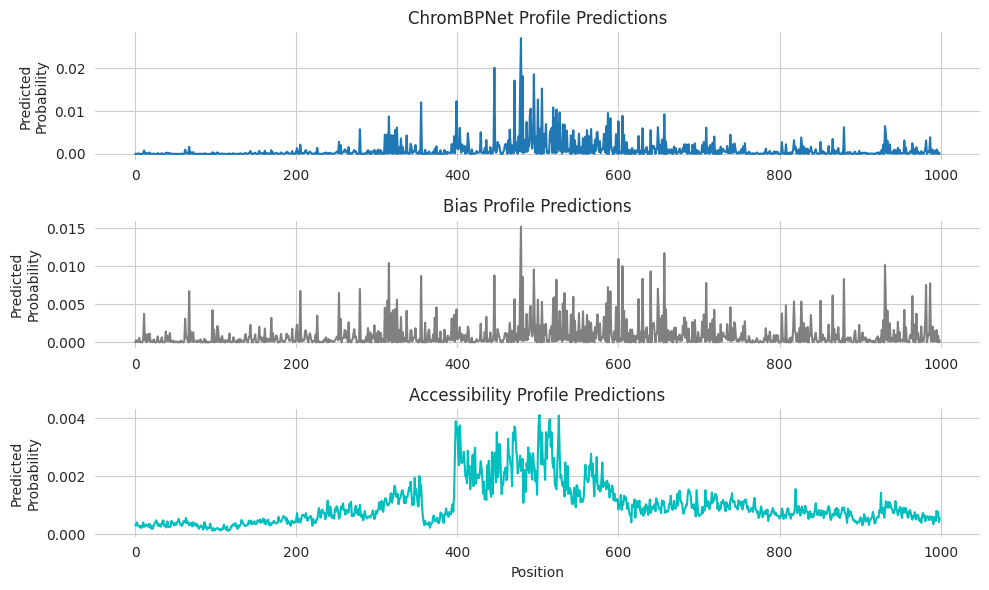

In [18]:
# Again, but on a new regions
idx = 50

plt.figure(figsize=(10, 6))

plt.subplot(311)
plt.title("ChromBPNet Profile Predictions")
plt.plot(y_softmax[idx, 0])
seaborn.despine(bottom=True, left=True)
plt.ylabel("Predicted\nProbability")

plt.subplot(312)
plt.title("Bias Profile Predictions")
plt.plot(y_bias_softmax[idx, 0], c='0.5')
seaborn.despine(bottom=True, left=True)
plt.ylabel("Predicted\nProbability")

plt.subplot(313)
plt.title("Accessibility Profile Predictions")
plt.plot(y_acc_softmax[idx, 0], c='c')
seaborn.despine(bottom=True, left=True)
plt.ylabel("Predicted\nProbability")
plt.xlabel("Position")

plt.tight_layout()
plt.show()

Different region shows a much different accessibility sequence. The middle is a lot more accessibility in the middle. 

The accessibility profile is a lot different than the chromBPnet raw profile, showing the model is getting rid of noise here. 

### **Attributions**

As well as making predictions using chromBPNet models, we can also consider their attributions.

Using methods like DeepLIFT can identify the nucleotides that are driving predicted accessibility.

In [21]:
# Style of DeepLift
# Runs a prediction on a sequence (idx)
# Output is the total predicted accessibility for the 1000bp region
from bpnetlite.bpnet import CountWrapper

counts_model = CountWrapper(chrombpnet.accessibility)

predict(counts_model, X[idx:idx+1])

tensor([[4.5755]])

Interpretation of above value:
- High values = open chromatin peak (>7)
- Moderate values = moderate accessibility open 
- Low values = closed chromatin (<2)

In [28]:
# Calculate attributions based on all 3 of them and compare
from bpnetlite.bpnet import ProfileWrapper
from bpnetlite.attribute import deep_lift_shap

X_attr0 = deep_lift_shap(ProfileWrapper(chrombpnet), X[idx:idx+1])
X_attr1 = deep_lift_shap(ProfileWrapper(chrombpnet.bias), X[idx:idx+1])
X_attr2 = deep_lift_shap(ProfileWrapper(chrombpnet.accessibility), X[idx:idx+1])

/scratch/users/k25055720/conda_envs/bpnet_lite/lib/python3.10/site-packages/tangermeme/deep_lift_shap.py:460: RuntimeWarning: Convergence deltas too high: tensor([0.1838, 1.3130, 0.4345, 0.5238, 0.7665, 0.4122, 0.5213, 0.2943, 0.3642,
        0.1530, 0.5793, 1.2028, 0.2640, 0.6318, 0.6354, 0.4929, 0.2730, 0.4160,
        0.8364, 0.0379], device='cuda:0', grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +
/scratch/users/k25055720/conda_envs/bpnet_lite/lib/python3.10/site-packages/tangermeme/deep_lift_shap.py:460: RuntimeWarning: Convergence deltas too high: tensor([0.2205, 0.0018, 0.1948, 0.1853, 0.0780, 0.2091, 0.1522, 0.0876, 0.2094,
        0.2229, 0.2486, 0.0006, 0.0889, 0.1547, 0.2436, 0.2021, 0.2428, 0.1589,
        0.1983, 0.1829], device='cuda:0', grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +


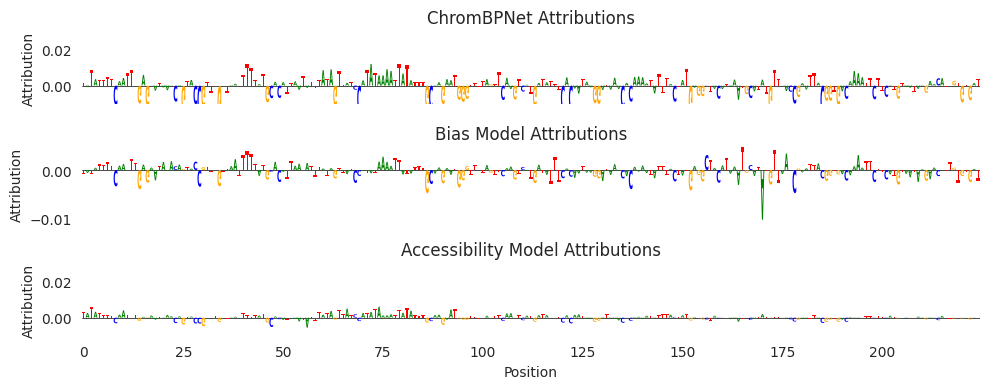

In [29]:
# Plot the above
from tangermeme.plot import plot_logo

s, e = 600, 825

plt.figure(figsize=(10, 4))
plt.subplot(311)
plt.title("ChromBPNet Attributions")
plot_logo(X_attr0[0, :, s:e])
plt.grid(False)
plt.ylim(-0.01, 0.03)
plt.xticks([], [])
plt.ylabel("Attribution")

plt.subplot(312)
plt.title("Bias Model Attributions")
plot_logo(X_attr1[0, :, s:e])
plt.grid(False)
plt.xticks([], [])
plt.ylabel("Attribution")

plt.subplot(313)
plt.title("Accessibility Model Attributions")
plot_logo(X_attr2[0, :, s:e])
plt.grid(False)
plt.ylim(-0.01, 0.03)
plt.xlabel("Position")
plt.ylabel("Attribution")

plt.tight_layout()
plt.show()

Right ok, this seems to point out that all attributions that came out of the uncorrected bias predictions were all just noise (?)

The final model has almost no signal output and peaks are a lot smaller. Shows that a lot was technical noise. 

### **Variant Effect Prediction**

This looks at how a mutation could have an effect on predicted accessibility.

In [32]:
from tangermeme.variant_effect import substitution_effect

variants = [
    [0, 640, 3]
]

before, after = substitution_effect(chrombpnet.accessibility, X[:1], variants)
before = torch.softmax(before[0], dim=-1)
after = torch.softmax(after[0], dim=-1)

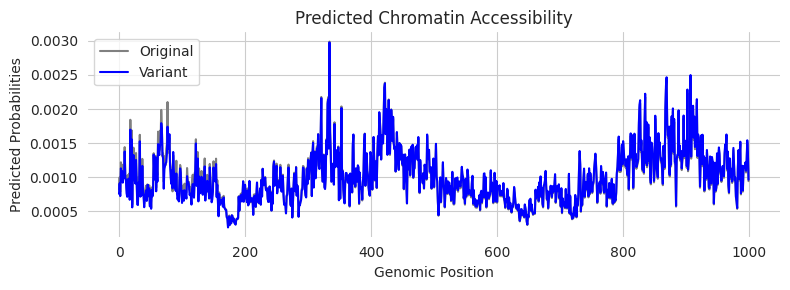

In [33]:
plt.figure(figsize=(8, 3))

plt.plot(before[0, 0], c='0.5', label="Original")
plt.plot(after[0, 0], c='b', label="Variant")

plt.title("Predicted Chromatin Accessibility")
plt.xlabel("Genomic Position")
plt.ylabel("Predicted Probabilities")

seaborn.despine(bottom=True, left=True)
plt.legend()

plt.tight_layout()
plt.show()

lol ok it doesn't change much. Would be better if I knew a specific variant change that changes the accessibility drastically.

### **Designing Differentially Accessible Regions**

This requires two different built models on different cell types:
One on lactotrophs for e.g. and one on somatotrophs

Uses the Ledidi package because it has a wrapping tool built-in and because the Ledidi design method is quite fast compared to other approaches.

In [ ]:
acc_model_2="/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/<model_path>"

In [ ]:
from ledidi.wrappers import DesignWrapper

designer = DesignWrapper([
    CountWrapper(chrombpnet.accessibility.cuda()),
    CountWrapper(acc_model_2.cuda())
])

The designer model output can be used just like a multi-task model. 
It can then make predictions on a sequence using tangermeme just like above.

In [ ]:
predict(designer, X[1:])

The ledidi design algorithm can be used to edit the sequence in a manner that achieves some desired output predictions. As a toy example, the below tries to diminish accessibility in the first cell type and increases accessibility in the second. 

In [ ]:
from ledidi import ledidi

y_bar = torch.tensor([[4.0, 9.0]])
X_bar = ledidi(designer, X[:1].float(), y_bar, verbose=True)

In [ ]:
predict(designer, X_bar)